In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

In [24]:
model_colors = ["goldenrod","salmon","lightseagreen"]
model_names = ["Laplacian", "Geometric", "GNN"]
measures_ids = {'Harmonic degree': 1, 'Conformal degree': 4, 'Harmonic deviation': 2}

In [8]:
os.path.join(res_path,p)

'pre_computed_measures/pw_results.pkl'

### Load pre-computed harmonic measures

In [29]:
res_path = "pre_computed_measures/"

compressions = {m:{} for m in model_names}
h_deg =  {m:{} for m in model_names}
c_deg =  {m:{} for m in model_names}
net_list = []

for p in os.listdir(res_path):
    if ".pkl" in p:
        net_list.append(p)
        with open(os.path.join(res_path,p),"rb") as f:
            results = pickle.load(f)
        n_nodes = len(results['Graph'])
        compressions['Laplacian'][p] = results['Laplacian compression list']
        compressions['Geometric'][p] = 1-np.array(results['Geometric graph length'])/n_nodes
        compressions['GNN'][p] = 1-np.array(results['GNN realn number of nodes'])/n_nodes

        h_deg['Laplacian'][p] = results['Laplacian Harmonic Modified']
        h_deg['Geometric'][p] = results['Geometric Harmonic Modified']
        h_deg['GNN'][p] = np.array(results['GNN DATA']).reshape(-1,6)[:,measures_ids['Harmonic degree']]

        c_deg['Laplacian'][p] = results['Laplacian Conformal Modified']
        c_deg['Geometric'][p] = results['Geometric Conformal Modified']
        c_deg['GNN'][p] = np.array(results['GNN DATA']).reshape(-1,6)[:,measures_ids['Conformal degree']]

### Plot all measures

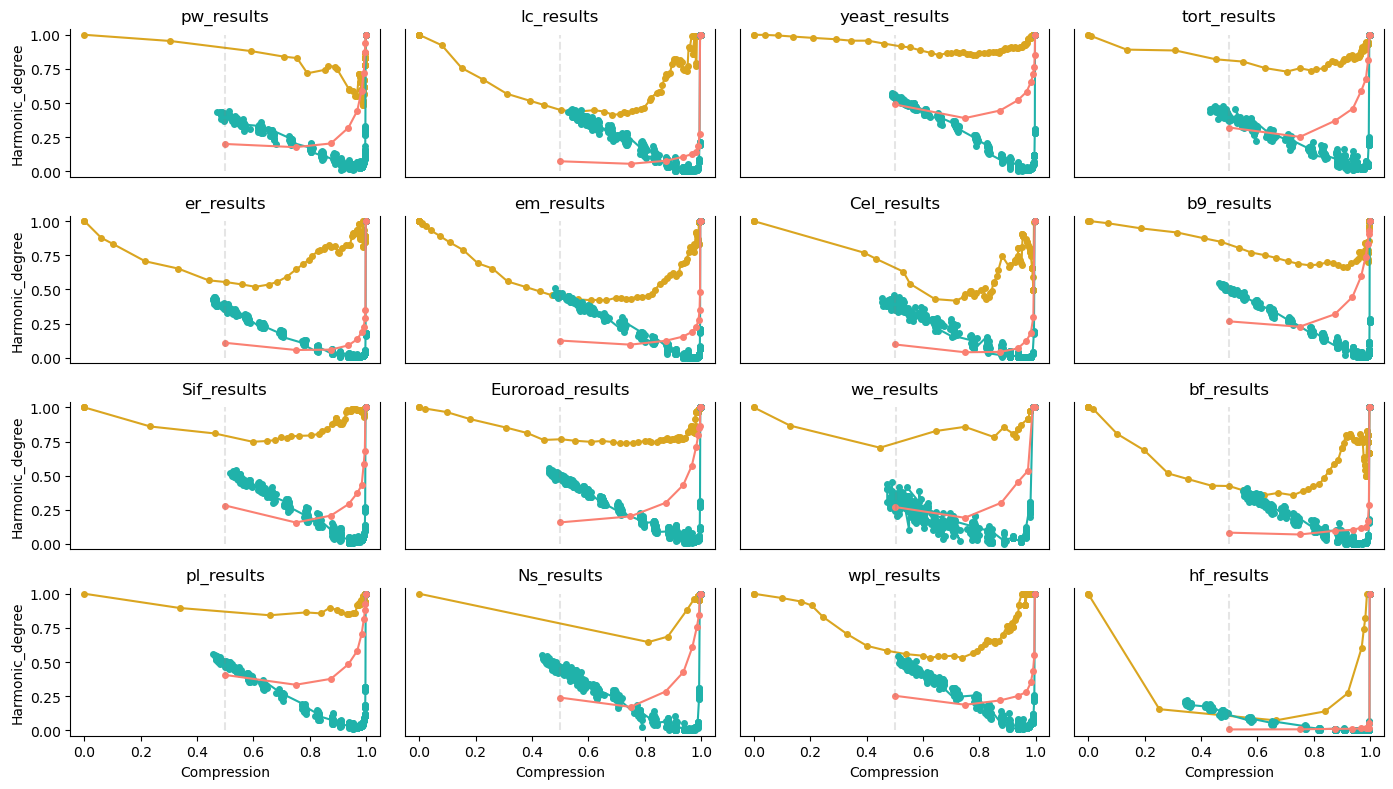

In [50]:
f = plt.figure(figsize=(14,8))

for i in range(len(net_list)):
    p = net_list[i]
    ax = plt.subplot(4,4,i+1)
    ax.plot(compressions['Laplacian'][p],h_deg['Laplacian'][p], '-o',color = model_colors[0], markersize=4)
    ax.plot(compressions['GNN'][p],h_deg['GNN'][p], '-o',color = model_colors[2], markersize=4)
    ax.plot(compressions['Geometric'][p],h_deg['Geometric'][p], '-o',color = model_colors[1], markersize=4)

    ax.set_ylim([-0.04,1.04])
    ax.set_title(p.split(".")[0])
    if i % 4 == 0:
        ax.set_ylabel("Harmonic_degree")
    else:
        ax.set_ylabel("")
        ax.set_yticks([])
    if i > 11:
        ax.set_xlabel("Compression")
    else:
        ax.set_xticks([])
    ax.vlines(0.5,0,1,color="gray",linestyles="dashed",alpha = 0.2)
    plt.gca().spines['top'].set_visible(False)

plt.tight_layout()

### Plot average

/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/numpy/core/_methods.py:152: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/numpy/core/_methods.py:173: Run

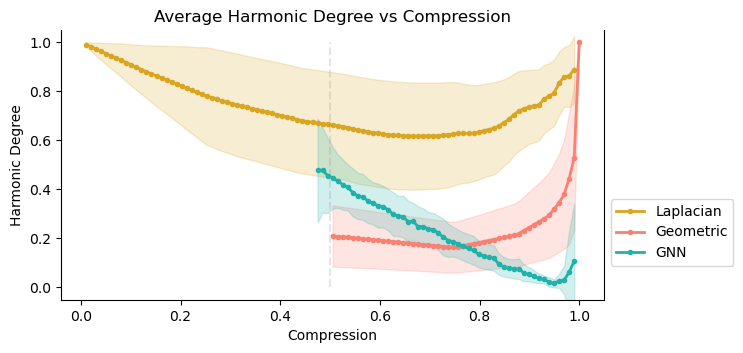

In [92]:
from scipy.interpolate import interp1d

# Create interpolation for each network

# Define common compression axis (0 to 1)
compression_axis = np.linspace(0, 1, 100,endpoint=True)

# Interpolate harmonic degree for each model and network
interpolated_data = {model: [] for model in model_names}

for model in model_names:
    for net in net_list:
        comp = compressions[model][net]
        h_d = h_deg[model][net]
        
        # Create interpolation function
        if model == "GNN":
            sort_id = np.argsort(comp)
            h_d = h_d[sort_id]
            comp = np.sort(comp)
            
        f_interp = interp1d(comp, h_d, kind='linear', fill_value='extrapolate')
        interpolated_data[model].append(f_interp(compression_axis))

# Convert to arrays and compute mean and std
interpolated_arrays = {model: np.array(interpolated_data[model]) for model in model_names}
means = {model: interpolated_arrays[model].mean(axis=0) for model in model_names}
stds = {model: interpolated_arrays[model].std(axis=0) for model in model_names}

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))

for i, model in enumerate(model_names):
    if model == "Geometric":
        ax.plot(compression_axis[len(compression_axis)//2:], 
                means[model][len(compression_axis)//2:], 
                '-o',color=model_colors[i], label=model, linewidth=2, markersize = 3)
        ax.fill_between(compression_axis[len(compression_axis)//2:], 
                    means[model][len(compression_axis)//2:] - stds[model][len(compression_axis)//2:], 
                    means[model][len(compression_axis)//2:] + stds[model][len(compression_axis)//2:], 
                    color=model_colors[i], alpha=0.2)
    else:
        ax.plot(compression_axis, means[model], '-o',color=model_colors[i], label=model, linewidth=2, markersize = 3)
        ax.fill_between(compression_axis, 
                        means[model] - stds[model], 
                        means[model] + stds[model], 
                        color=model_colors[i], alpha=0.2)

ax.vlines(0.5,0,1,color="gray",linestyles="dashed",alpha = 0.2)
ax.set_xlabel('Compression')
ax.set_ylabel('Harmonic Degree')
ax.set_title('Average Harmonic Degree vs Compression')
ax.legend(ncols = 1, bbox_to_anchor = (1,0.4))
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)
#plt.savefig("average.pdf", bbox_inches='tight')